# epiCRealism LoRA Training (Every 20 Images Progress)
This version uses the Service Role Key and reports progress every 20 images.

In [3]:
# 1. Install Required Libraries
!pip install supabase python-dotenv diffusers transformers accelerate xformers
!git clone https://github.com/kohya-ss/sd-scripts.git
%cd sd-scripts
!pip install -r requirements.txt

Cloning into 'sd-scripts'...
remote: Enumerating objects: 11494, done.
remote: Counting objects: 100% (408/408), done.
remote: Compressing objects: 100% (236/236), done.
remote: Total 11494 (delta 284), reused 172 (delta 172), pack-reused 11086 (from 3)
Receiving objects: 100% (11494/11494), 18.62 MiB | 26.20 MiB/s, done.
Resolving deltas: 100% (8134/8134), done.
/kaggle/working/sd-scripts/sd-scripts
Obtaining file:///kaggle/working/sd-scripts/sd-scripts (from -r requirements.txt (line 49))
  Preparing metadata (setup.py) ... done
  Attempting uninstall: library
    Found existing installation: library 0.0.0
    Uninstalling library-0.0.0:
      Successfully uninstalled library-0.0.0
  Running setup.py develop for library


In [8]:
# 3. Download Dataset (With Progress and Error Logging)
import os
os.makedirs('/kaggle/working/dataset/10_interior', exist_ok=True)
all_records = []
batch_size = 1000
start = 0

print("Fetching records from Supabase...")
while True:
    try:
        response = supabase.table("augmented_images").select("image_url, prompt").range(start, start + batch_size - 1).execute()
        data = response.data
        if not data: break
        all_records.extend(data)
        start += batch_size
        if len(data) < batch_size: break
    except Exception as e:
        print(f"Error fetching records: {str(e)}")
        break

total_files = len(all_records)
print(f"Total records found: {total_files}. Starting download...")

download_count = 0
for i, record in enumerate(all_records):
    url = record['image_url']
    path = f"/kaggle/working/dataset/10_interior/aug_{i:04d}.jpg"
    
    if os.path.exists(path): 
        continue
        
    try:
        data = supabase.storage.from_("Augmented Images").download(url)
        with open(path, "wb") as f: 
            f.write(data)
        
        # Caption file creation
        with open(path.replace('.jpg', '.txt'), "w") as f: 
            f.write(f"{record.get('prompt', '')}, epiCRealism style")
        
        download_count += 1
        
        # Progress check
        if download_count % 20 == 0:
            print(f"Progress: {download_count} images downloaded...")

    except Exception as e:
        print(f"Error at image {i} (URL: {url}): {str(e)}")
        continue

print(f"Download Finished! Total new images: {download_count}")

Fetching records from Supabase...
Total records found: 1256. Starting download...
Progress: 20 images downloaded...
Progress: 40 images downloaded...
Progress: 60 images downloaded...
Progress: 80 images downloaded...
Progress: 100 images downloaded...
Progress: 120 images downloaded...
Progress: 140 images downloaded...
Progress: 160 images downloaded...
Progress: 180 images downloaded...
Download Finished! Total new images: 199


In [2]:
# Download EpicRealism Model

MODEL_URL = "https://civitai.com/api/download/models/134065"

!mkdir -p /kaggle/working/model

!wget -O /kaggle/working/model/epiCRealism.safetensors $MODEL_URL

print("Model downloaded successfully!")

--2026-05-17 09:59:51--  https://civitai.com/api/download/models/134065
Resolving civitai.com (civitai.com)... 104.20.38.219, 172.66.152.186, 2606:4700:10::6814:26db, ...
Connecting to civitai.com (civitai.com)|104.20.38.219|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://b2.civitai.com/file/civitai-modelfiles/81744/model/epicrealism.84xo.safetensors?Authorization=3_20260517095505_25a1fa901e6856fd2d991624_ba2b54c2e6a2d7abe71391662778c96b83ffa1cf_004_20260517105505_0040_dnld&b2ContentDisposition=attachment%3B+filename%3D%22epicrealism_pureEvolutionV5.safetensors%22 [following]
--2026-05-17 09:59:51--  https://b2.civitai.com/file/civitai-modelfiles/81744/model/epicrealism.84xo.safetensors?Authorization=3_20260517095505_25a1fa901e6856fd2d991624_ba2b54c2e6a2d7abe71391662778c96b83ffa1cf_004_20260517105505_0040_dnld&b2ContentDisposition=attachment%3B+filename%3D%22epicrealism_pureEvolutionV5.safetensors%22
Resolving b2.civitai.com (b2.civit

In [ ]:
## OPTION A: Standard Balanced (Experiment 1)
!accelerate launch --num_cpu_threads_per_process=2 /kaggle/working/sd-scripts/train_network.py \
    --pretrained_model_name_or_path=/kaggle/working/model/epiCRealism.safetensors \
    --train_data_dir=/kaggle/working/dataset \
    --output_dir=/kaggle/working/output \
    --output_name="lora_standard" \
    --resolution=512,512 \
    --train_batch_size=1 \
    --learning_rate=1e-4 \
    --max_train_steps=2000 \
    --network_module=networks.lora \
    --network_dim=32 \
    --network_alpha=16 \
    --mixed_precision=fp16 \
    --save_model_as=safetensors \
    --enable_bucket \
    --caption_extension=".txt"

In [ ]:
## OPTION B: High Rank/Detail (Experiment 2)
# !accelerate launch --num_cpu_threads_per_process=2 /kaggle/working/sd-scripts/train_network.py \
#     --pretrained_model_name_or_path=/kaggle/working/model/epiCRealism.safetensors \
#     --train_data_dir=/kaggle/working/dataset \
#     --output_dir=/kaggle/working/output \
#     --output_name="lora_high_dim" \
#     --resolution=512,512 \
#     --train_batch_size=1 \
#     --learning_rate=1e-4 \
#     --max_train_steps=2000 \
#     --network_module=networks.lora \
#     --network_dim=128 \
#     --network_alpha=64 \
#     --mixed_precision=fp16 \
#     --save_model_as=safetensors \
#     --enable_bucket \
 #    --caption_extension=".txt"

In [21]:
### OPTION C: High LR & Steps (Experiment 3)
!accelerate launch --num_cpu_threads_per_process=2 /kaggle/working/sd-scripts/train_network.py \
    --pretrained_model_name_or_path=/kaggle/working/model/epiCRealism.safetensors \
    --train_data_dir=/kaggle/working/dataset \
    --output_dir=/kaggle/working/output \
    --output_name="lora_aggressive" \
    --resolution=512,512 \
    --train_batch_size=1 \
    --learning_rate=2e-4 \
    --max_train_steps=3000 \
    --network_module=networks.lora \
    --network_dim=32 \
    --network_alpha=16 \
    --mixed_precision=fp16 \
    --save_model_as=safetensors \
    --enable_bucket \
    --caption_extension=".txt"


	`--num_processes` was set to a value of `2`
		More than one GPU was found, enabling multi-GPU training.
		If this was unintended please pass in `--num_processes=1`.
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-16 19:45:28.177275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778960728.201887     605 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778960728.209989     605 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-16 19:45:28.2180

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

  0%|          | 0/30 [00:00<?, ?it/s]

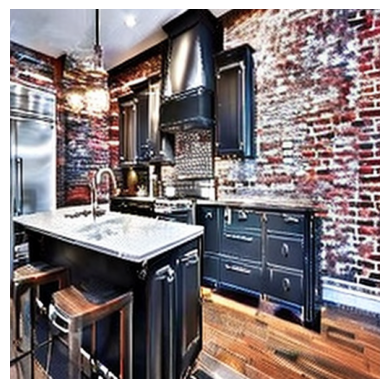

In [3]:
## 6. Test Your Trained LoRA
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

model_path = "/kaggle/working/model/epiCRealism.safetensors"
lora_path = "/kaggle/input/datasets/zobianasim/epicrealism-interior-design-lora/last (1).safetensors"

pipe = StableDiffusionPipeline.from_single_file(model_path, torch_dtype=torch.float16).to("cuda")
pipe.load_lora_weights(lora_path)

prompt = "An industrial style kitchen with brick walls, black cabinets, hanging Edison bulbs, stainless steel appliances epiCRealism style"
image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

plt.imshow(image)
plt.axis('off')
plt.show()
image.save("test_result.png")

/kaggle/working/sd-scripts/output/last.safetensors

In [22]:
import shutil

shutil.copy(
    '/kaggle/working/output/lora_aggressive.safetensors',
    '/kaggle/working/my_trained_model.safetensors'
)

print("Model saved successfully!")

Model saved successfully!


In [24]:
import os
os.chdir('/kaggle/working') # Wapas main folder mein aa jayein
from IPython.display import FileLink
FileLink(r'output/lora_aggressive.safetensors')



/kaggle/working/output/lora_aggressive.safetensors